In [1]:
#!/usr/bin/env python3
import cv2
import csv
import glob
import time
import imutils
import numpy as np
import mediapipe as mp
import mp_utils as mu
from matplotlib import pyplot as plt
from imutils.object_detection import non_max_suppression

mp_pose = mp.solutions.pose
mp_hands = mp.solutions.hands
mp_face_mesh = mp.solutions.face_mesh
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

##### YOLO Object Detection - image files - 320, 416, 608

In [2]:
# For static images:
files = glob.glob(".\\image\\*.jpg") 
output_dir = ".\output\\"
print(len(files))
for filename in files:
  print(filename)

6
.\image\00047.jpg
.\image\00049.jpg
.\image\00101.jpg
.\image\avengers.jpg
.\image\persons0.jpg
.\image\persons1.jpg


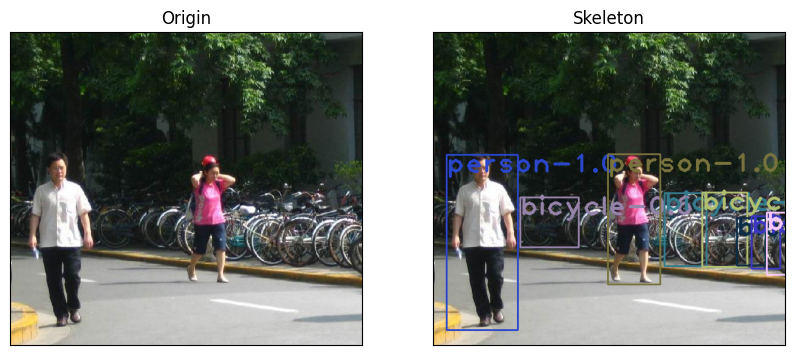

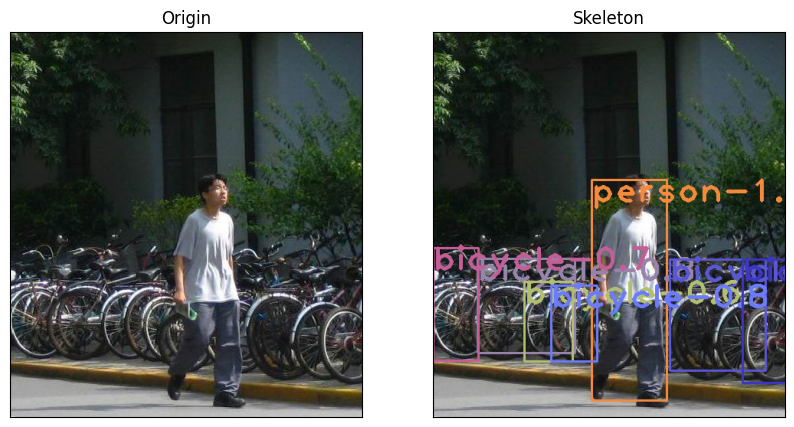

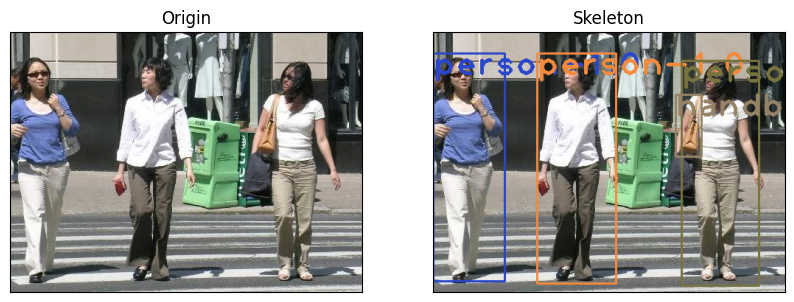

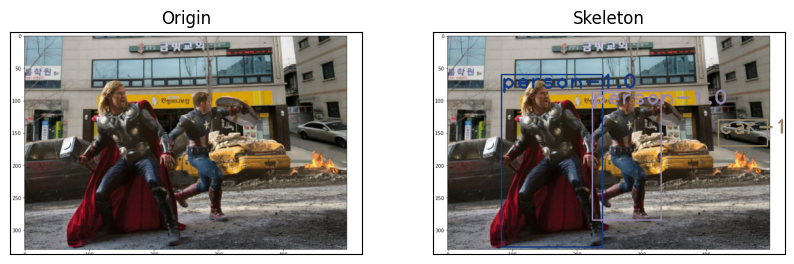

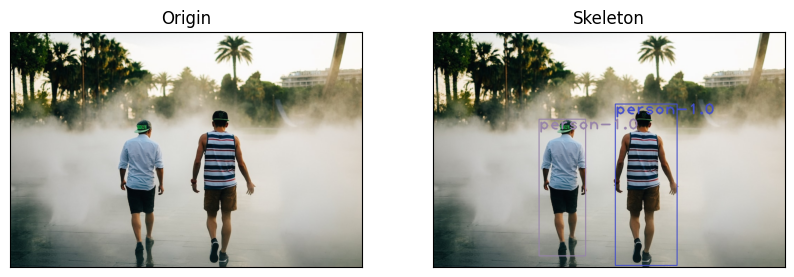

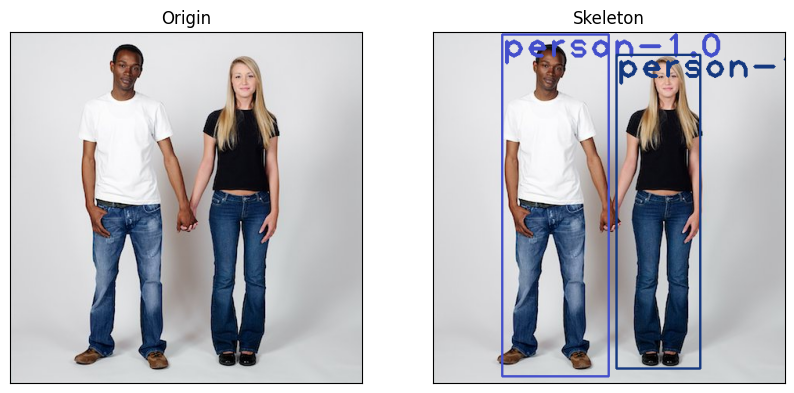

In [3]:
# Yolo 로드
net = cv2.dnn.readNet("yolo3/yolov3.weights", "yolo3/yolov3.cfg")
# https://pjreddie.com/darknet/yolo/
# https://github.com/pjreddie/darknet/blob/master/data/coco.names
classes = []
with open("yolo3/coco.names", "r") as f:
  classes = [line.strip() for line in f.readlines()]
layer_names = net.getLayerNames()
output_layers = [layer_names[i-1] for i in net.getUnconnectedOutLayers()]
colors = np.random.uniform(0, 255, size=(len(classes), 3))

font = cv2.FONT_HERSHEY_PLAIN
display_skeleton = 1

for idx, file in enumerate(files):
  image = cv2.imread(file)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
  annotated_image = image.copy()

  height, width, _ = image.shape
  # Convert the BGR image to RGB before processing.

  # Detecting objects
  blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
  net.setInput(blob)
  outs = net.forward(output_layers)

  # 정보를 화면에 표시
  class_ids = []
  confidences = []
  boxes = []
  for out in outs:
    for detection in out:
      scores = detection[5:]
      class_id = np.argmax(scores)
      confidence = scores[class_id]
      if confidence > 0.5:
        # Object detected
        center_x = int(detection[0] * width)
        center_y = int(detection[1] * height)
        w = int(detection[2] * width)
        h = int(detection[3] * height)
        # 좌표
        x = int(center_x - w / 2)
        y = int(center_y - h / 2)
        boxes.append([x, y, w, h])
        confidences.append(float(confidence))
        class_ids.append(class_id)

  indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

  for i in range(len(boxes)):
    if i in indexes:
      x, y, w, h = boxes[i]
      label = "%s-%3.1f" % (classes[class_ids[i]], confidences[i])
      color = colors[i]
      cv2.rectangle(annotated_image, (x, y), (x + w, y + h), color, 2)
      cv2.putText(annotated_image, label, (x, y + 30), font, 3, color, 3)

  if display_skeleton:
    plt.figure(figsize = (10,7))
    plt.subplot(1,2,1), plt.imshow(image)
    plt.title('Origin'), plt.xticks([]), plt.yticks([])
    plt.subplot(1,2,2), plt.imshow(annotated_image)
    plt.title('Skeleton'), plt.xticks([]), plt.yticks([])
    plt.show()

  list = file.split('\\')[2].split('.')
  output = output_dir+'obj_'+list[0]+'.jpg'
  annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
  
  cv2.imwrite(output, annotated_image)

##### YOLO Object Detection - camera - 320, 416, 608

In [ ]:
width, height = 640, 480
# width, height = 1920, 1080
cap, fps = mu.setCamera(0, width, height)

display_scale = 1
title = "Yolo v3"
mu.setCVWindows(title, display_scale, 0)

save_skeleton = False
if save_skeleton:
    output_dir = ".\output\\"
    stime = time.strftime('%Y%m%d%H%M', time.localtime())
    outputvideo = output_dir + "video_" + stime + ".mp4" 
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(outputvideo, fourcc, fps, (width, height))

frameCount = 0
start = time.time()
delay_time = int(1000/fps)
font = cv2.FONT_HERSHEY_SIMPLEX

# Yolo 로드
net = cv2.dnn.readNet("yolo3/yolov3.weights", "yolo3/yolov3.cfg")
classes = []
with open("yolo3/coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]
layer_names = net.getLayerNames()
output_layers = [layer_names[i-1] for i in net.getUnconnectedOutLayers()]
colors = np.random.uniform(0, 255, size=(len(classes), 3))

while cap.isOpened():
    success, frame = cap.read()
    if not success:
      continue

    frameCount += 1
    frame = cv2.flip(frame, 1)
    height, width, _ = frame.shape
    # Convert the BGR image to RGB before processing.
  
    # Detecting objects
    blob = cv2.dnn.blobFromImage(frame, 0.00392, (416, 416), (0, 0, 0), True, crop=False)
    net.setInput(blob)
    outs = net.forward(output_layers)

    # 정보를 화면에 표시
    class_ids = []
    confidences = []
    boxes = []
    for out in outs:
        for detection in out:
            scores = detection[5:]
            class_id = np.argmax(scores)
            confidence = scores[class_id]
            if confidence > 0.5:
                # Object detected
                center_x = int(detection[0] * width)
                center_y = int(detection[1] * height)
                w = int(detection[2] * width)
                h = int(detection[3] * height)
                # 좌표
                x = int(center_x - w / 2)
                y = int(center_y - h / 2)
                boxes.append([x, y, w, h])
                confidences.append(float(confidence))
                class_ids.append(class_id)

    indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

    for i in range(len(boxes)):
        if i in indexes:
            x, y, w, h = boxes[i]
            label = "%s-%3.1f" % (classes[class_ids[i]], confidences[i])
            color = colors[i]
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
            cv2.putText(frame, label, (x, y + 30), font, 3, color, 3)

    # Flip the image horizontally for a selfie-view display.
    seconds = time.time() - start
    fps  = frameCount / seconds
    msg = "fps{:.2f}".format(fps) + " - {0}".format(frameCount)+ "/{:.2f}".format(seconds)
    cv2.putText(frame, msg, (10, 30), font, 0.6, (255,0,0), 1, cv2.LINE_AA)
    cv2.imshow(title, frame)
    if save_skeleton:
        out.write(frame)

    key = cv2.waitKey(delay_time) & 0xFF
    if key == ord('q') or key == 27:
        break
if save_skeleton:  
    out.release()    
cap.release()
cv2.destroyAllWindows()